# Dataset 2 — MIMIC-III (Mortalidad Hospitalaria)
## Descripción general
El **MIMIC-III (Medical Information Mart for Intensive Care)** es una base de datos clínica 
de acceso libre desarrollada por el MIT, que contiene información de **más de 40,000 pacientes** 
admitidos en la Unidad de Cuidados Intensivos (UCI) del Beth Israel Deaconess Medical Center 
entre los años 2001 y 2012. Para este trabajo se utilizó la versión demo con **129 admisiones** 
y **100 pacientes únicos**, obtenida uniendo las tablas `ADMISSIONS.csv` y `PATIENTS.csv`.

## Objetivo
**Problema de Clasificación Binaria** — predecir si un paciente fallecerá durante 
su hospitalización (`hospital_expire_flag = 1`) o sobrevivirá (`hospital_expire_flag = 0`), 
en función de sus características demográficas y de admisión.

## Estructura original
- **ADMISSIONS:** 129 filas, 19 columnas
- **PATIENTS:** 100 filas, 8 columnas
- **Dataset unido (merge):** 129 filas, 26 columnas
- **Variable objetivo:** `hospital_expire_flag` (0 = sobrevivió, 1 = falleció)
- **Distribución inicial:** 89 pacientes sobrevivieron (69%), 40 fallecieron (31%)

## Tipos de columnas (tras el merge)
| Tipo | Ejemplos |
|------|---------|
| Categóricas (texto) | gender, admission_type, insurance, religion, marital_status, ethnicity |
| Fechas (descartadas) | admittime, dischtime, deathtime, dob, dod |
| Identificadores (descartados) | subject_id, hadm_id, row_id |
| Numéricas binarias | hospital_expire_flag, expire_flag, has_chartevents_data |

## Columnas seleccionadas para el modelo
De las 26 columnas del merge, se conservaron solo las de **alto impacto predictivo**:
- `gender` → sexo biológico del paciente
- `admission_type` → tipo de ingreso (urgencia, electivo, recién nacido)
- `admission_location` → origen de la admisión (emergencia, transferencia, etc.)
- `discharge_location` → destino al dar el alta (casa, otra institución, morgue, etc.)
- `insurance` → tipo de seguro médico (Medicare, Medicaid, privado, etc.)
- `religion` → religión del paciente
- `marital_status` → estado civil
- `ethnicity` → etnia del paciente
- `hospital_expire_flag` → si el paciente falleció en el hospital (**variable objetivo**)

## Valores faltantes encontrados
| Columna | NaN | % |
|---------|-----|---|
| `language` | 48 | 37.2% |
| `marital_status` | 16 | 12.4% |
| `religion` | 1 | 0.8% |

## Tratamiento aplicado

### 1. Unión de tablas (Merge)
Se unieron `ADMISSIONS` y `PATIENTS` mediante `subject_id` con un `inner join`, 
obteniendo un único dataset con toda la información relevante por paciente.

### 2. Eliminación de columnas inútiles
Se eliminaron **16 columnas** que no aportan valor predictivo:
- **Identificadores:** `row_id_x`, `row_id_y`, `hadm_id`, `subject_id` — son solo números internos.
- **Fechas crudas:** `admittime`, `dischtime`, `deathtime`, `edregtime`, `edouttime`, `dob`, `dod`, `dod_hosp`, `dod_ssn` — requerirían ingeniería de características adicional para ser útiles.
- **Columnas redundantes o técnicas:** `has_chartevents_data`, `expire_flag` (duplica la variable objetivo), `diagnosis` (texto libre que requeriría NLP).

### 3. Eliminación de columnas con >50% de NaN
Ninguna columna superó el umbral del 50% de valores faltantes, 
por lo que no se eliminó ninguna columna en este paso.

### 4. Imputación de NaN restantes
- **Columnas numéricas** → imputadas con la **mediana** de cada columna,
  por ser más robusta frente a valores extremos que el promedio.
- **Columnas de texto** → imputadas con la etiqueta `'Desconocido'`
  para indicar explícitamente que la información no estaba disponible.

### 5. Codificación de variables categóricas (One-Hot Encoding)
Las 9 columnas de texto fueron convertidas a números mediante **one-hot encoding**
(`pd.get_dummies()`), generando una columna binaria (0 o 1) por cada valor posible,
pasando de 9 columnas a 57 columnas binarias.

### 6. Balanceo de clases (Undersampling)
El dataset original estaba **desbalanceado**: 69% sobrevivió vs 31% falleció.
Entrenar un modelo con esta distribución lo sesgaría a predecir siempre "sobrevive".
Se aplicó **Undersampling** — reducir aleatoriamente la clase mayoritaria (sobrevivió)
para que ambas clases queden con el mismo número de muestras (40 cada una).

### 7. División de los datos (Train/Test Split)
Para evaluar correctamente la capacidad de generalización del modelo, el dataset resultante se dividió en dos subconjuntos:
- **Datos de Entrenamiento (80%):** Utilizados para enseñar y ajustar los pesos del algoritmo matemático.
- **Datos de Prueba (20%):** Reservados estrictamente para validar la precisión del modelo en datos que nunca antes ha visto.

### 8. Normalización (Estandarización)
Dado que los algoritmos de Machine Learning y el Descenso de Gradiente son sensibles a las diferencias de escala numéricas, se aplicó una estandarización matemática (media 0 y desviación estándar 1).
- **Prevención de Data Leakage (Fuga de datos):** La media (μ) y la desviación estándar (σ) se calcularon **únicamente** sobre los datos de entrenamiento. Posteriormente, esos mismos valores se usaron para escalar el conjunto de prueba.
- Finalmente, se añadió una columna de unos (1) a las matrices de características (X) para representar el término de sesgo (intercepto o θ₀).

## Resultado final
| | Antes | Después |
|--|-------|---------|
| Filas | 129 | 80 (balanceadas y divididas 80/20) |
| Columnas | 26 | 58 (más la columna de sesgo) |
| Valores faltantes | 65 | 0 |
| Columnas de texto | 9 | 0 |
| Balance de clases | 69% / 31% | 50% / 50% |

## ¿Está balanceado?
Sí. Este es un problema de **clasificación binaria** y el dataset original presentaba 
un desbalance moderado (69% vs 31%). Se aplicó **Undersampling** para igualar las clases 
a 50/50, evitando que el modelo aprenda a ignorar la clase minoritaria (fallecidos).
Un modelo sesgado en este contexto médico sería especialmente peligroso, ya que 
fallar en predecir una muerte tiene consecuencias críticas.

Shape original (después del merge): (129, 26)

Variable objetivo - hospital_expire_flag (0=Vive, 1=Fallece):
hospital_expire_flag
0    89
1    40
Name: count, dtype: int64

Shape después de filtrar columnas útiles: (129, 9)

Columnas eliminadas por tener >50% de NaN:
  Ninguna columna superó el 50% de nulos.
  religion: NaN imputados con 'Desconocido'
  marital_status: NaN imputados con 'Desconocido'

NaN restantes: 0
Shape después de one-hot encoding: (129, 52)

Balanceando las clases (Undersampling)...
Distribución después del balanceo:
hospital_expire_flag
0    40
1    40
Name: count, dtype: int64

=== DESCRIPCIÓN DEL DATASET PREPARADO ===
Nombre: MIMIC-III (Medical Information Mart for Intensive Care)
Problema: Clasificación Binaria — predecir mortalidad hospitalaria
Filas: 80 (balanceadas 50/50)
Columnas totales: 52
Variable objetivo: hospital_expire_flag (0=Vive, 1=Fallece)
NaN restantes: 0

Tratamiento aplicado:
  - Merge de ADMISSIONS y PATIENTS por subject_id
  - Filtrado a 9 

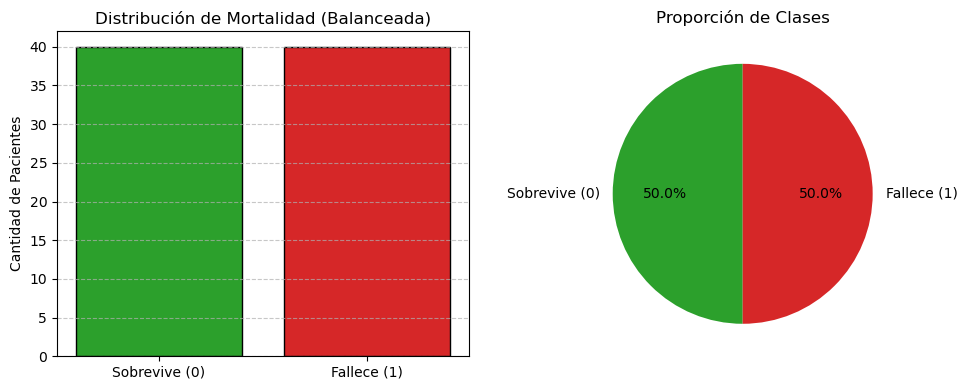

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGAR
adm = pd.read_csv(r'C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset2\mimic-iii-clinical-database-demo-1.4\mimic-iii-clinical-database-demo-1.4\ADMISSIONS.csv')
pat = pd.read_csv(r'C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset2\mimic-iii-clinical-database-demo-1.4\mimic-iii-clinical-database-demo-1.4\PATIENTS.csv')

df = pd.merge(adm, pat, on='subject_id', how='inner')

print("Shape original (después del merge):", df.shape)
print("\nVariable objetivo - hospital_expire_flag (0=Vive, 1=Fallece):")
print(df['hospital_expire_flag'].value_counts())

# 2. SELECCIONAR COLUMNAS ÚTILES
cols_utiles = ['gender', 'admission_type', 'admission_location',
               'discharge_location', 'insurance', 'religion',
               'marital_status', 'ethnicity', 'hospital_expire_flag']
df = df[cols_utiles]
print("\nShape después de filtrar columnas útiles:", df.shape)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
print("\nColumnas eliminadas por tener >50% de NaN:")
if cols_muchos_nulos:
    for col in cols_muchos_nulos:
        pct = df[col].isnull().sum() / len(df) * 100
        print(f"  {col}: {pct:.1f}% nulos")
else:
    print("  Ninguna columna superó el 50% de nulos.")
df = df.drop(columns=cols_muchos_nulos)

# 4. IMPUTAR NaN RESTANTES
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numericas:
    if col == 'hospital_expire_flag':
        continue
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f"  {col}: NaN imputados con mediana ({mediana})")

cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Desconocido')
        print(f"  {col}: NaN imputados con 'Desconocido'")

print("\nNaN restantes:", df.isnull().sum().sum())

# 5. ONE-HOT ENCODING
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns.tolist())
print("Shape después de one-hot encoding:", df.shape)

# 6. BALANCEAR CLASES (Undersampling)
print("\nBalanceando las clases (Undersampling)...")
clase_mayoritaria = df[df['hospital_expire_flag'] == 0]
clase_minoritaria = df[df['hospital_expire_flag'] == 1]

clase_mayoritaria_reducida = clase_mayoritaria.sample(n=len(clase_minoritaria), random_state=42)
df = pd.concat([clase_mayoritaria_reducida, clase_minoritaria])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribución después del balanceo:")
print(df['hospital_expire_flag'].value_counts())

# 7. MOVER hospital_expire_flag AL FINAL
cols = [c for c in df.columns if c != 'hospital_expire_flag'] + ['hospital_expire_flag']
df = df[cols]

# 8. RESUMEN FINAL
print("\n=== DESCRIPCIÓN DEL DATASET PREPARADO ===")
print(f"Nombre: MIMIC-III (Medical Information Mart for Intensive Care)")
print(f"Problema: Clasificación Binaria — predecir mortalidad hospitalaria")
print(f"Filas: {df.shape[0]} (balanceadas 50/50)")
print(f"Columnas totales: {df.shape[1]}")
print(f"Variable objetivo: hospital_expire_flag (0=Vive, 1=Fallece)")
print(f"NaN restantes: {df.isnull().sum().sum()}")
print(f"\nTratamiento aplicado:")
print(f"  - Merge de ADMISSIONS y PATIENTS por subject_id")
print(f"  - Filtrado a 9 columnas de alto impacto predictivo")
print(f"  - NaN de texto imputados con 'Desconocido'")
print(f"  - Variables categóricas convertidas con one-hot encoding")
print(f"  - Balanceo de clases por Undersampling (50/50)")
print(f"  - Columnas resultantes: {df.shape[1]}")

# 9. GUARDAR EL CSV COMO RESPALDO
df.to_csv('MIMIC_preparado.csv', index=False)
print("\nDataset guardado como 'MIMIC_preparado.csv' ")


# DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA

print("\n=== INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ===")

# Separar características (X) y la variable objetivo (y)
X = df.drop('hospital_expire_flag', axis=1).values
y = df['hospital_expire_flag'].values

# Calcular el índice de corte para el 80%
m = len(y)
limite = int(m * 0.8)

# División 80/20 (el dataset ya fue desordenado en el paso 6)
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual para Normalizar (Estandarización)
def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    # Evitar divisiones por cero si hay columnas constantes
    sigma[sigma == 0] = 1 
    X_norm = (X_data - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos usando SOLO los datos de entrenamiento
X_train_norm, mu, sigma = normalizar(X_train)

# Aplicamos la MISMA escala a los datos de prueba
X_test_norm = (X_test - mu) / sigma

# Agregar la columna de unos (Término de sesgo/Intercepto) a ambos conjuntos
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("¡Variables en memoria listas para el modelo matemático!")
print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño y_train:      {y_train.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")
print(f"Tamaño y_test:       {y_test.shape}")

# 10. GRÁFICAS 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
conteos = df['hospital_expire_flag'].value_counts()
plt.bar(['Sobrevive (0)', 'Fallece (1)'], conteos.values,
        color=['#2ca02c', '#d62728'], edgecolor='black')
plt.title("Distribución de Mortalidad (Balanceada)")
plt.ylabel("Cantidad de Pacientes")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.pie(conteos.values, labels=['Sobrevive (0)', 'Fallece (1)'],
        autopct='%1.1f%%', colors=['#2ca02c', '#d62728'], startangle=90)
plt.title("Proporción de Clases")

plt.tight_layout()
plt.show()